In [2]:
%reload_ext autoreload
%autoreload 2

import importlib

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from draw_rectangles import draw_rect, draw_riemann_rectangles
import solve_integrals as si

sp.init_printing()

# Understanding Integrals Through Real-World Applications

## 1. Introduction

Integrals are a mathematical tool for calculating quantities that acumulate or change continuously.
They can be used to find areas, distances, volumes and many other quantities

In physics, engineering, economics, and data science, many real-world quantities change continuously rather than remaining constant.

Integration provides a way to combine these changing quantities into a meaningful total.

### 1.1 An Example: Areas of Simple Shapes

Areas of simple geometric shapes are relatively easy to calculate because their dimensions can be described using known formulas. 

* A rectangle, for example, can be calculated using $A = width \times height$.
* The area of a triangle can be calculated using $A = \frac{1}{2}bh$.

### 1.2 What About the Area Under a Curve

We will investigate the area under the curve $f(x)=x^2$ between $x=0$ and $x=2$.

In other words, we want to calculate the region bounded by the curve, the x-axis, and the two verticals.

* lower boundary: $x = 0$
* upper boundary: $x = 2$
* curve: $f(x) = x^2$
* lower horizontal boundary: $y = 0$




### 1.3 Visualizing the Problem

To better understand the problem, we can visualise the region under the curve $f(x) = x^2$, that we want to calculate.

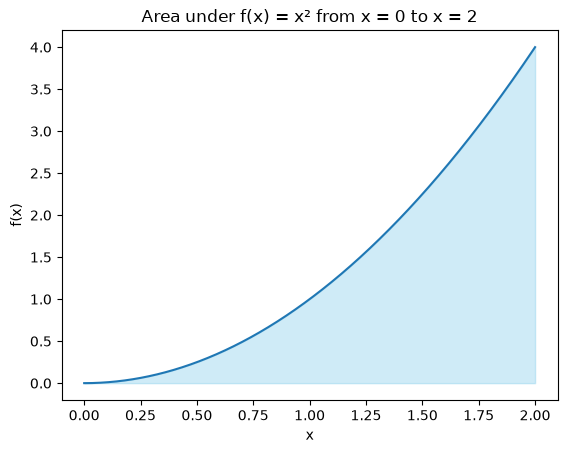

In [3]:

x = np.linspace(0, 2, 1000)
y = x**2

plt.plot(x, y)
plt.fill_between(x, y, color="skyblue", alpha=0.4)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Area under f(x) = x² from x = 0 to x = 2")
plt.show()


### 1.4 Area Under a Curve

We see that the height changes continuously along the curve:
* At $x = 0$, the height is $0^2 = 0$
* At $x = 1$, the height is $1^2 = 1$
* At $x = 2$, the height is $2^2 = 4$

Therefore, $width * height$ cannot be used directly because there is no single height for the entire region.

Instead, we can approximate the area using shapes whose areas we already know how to calculate. The simple choice is a rectangle.

How can we calculate the area under the curve using rectangles?


## 2. Approximating the Area with Rectangles

### 2.1 Dividing the interval

Let's continue with $y = x^2$ from $x=0$ to $x = 2$

For example - let's use 4 rectangles, the interval length is $2 - 0 = 2$

With 4 rectangles, each rectangle has width $\Delta x = \frac{2}{4} = 0.5$ 

The x values would be $0, 0.5, 1, 1.5, 2$, so we can calculate the heights with $x^2$

### 2.2 Approximating with Rectangles

At first we can approximate the height by using the **left edge** of the rectangle
* First rectangle is in our first interval $0 \leq x \leq 0.5$. 
    * $f(0) = 0^2 = 0$. 
    * $A_1 = 0.5 \times 0 = 0$
* Second rectangle interval $0.5 \leq x \leq 1$. 
    * $f(0.5) = 0.5^2 = 0.25$. 
    * $A_2 = 0.5 \times 0.25 = 0.125$
* Third rectangle interval $1 \leq x \leq 1.5$.
    * $f(1) = 1^2 = 1$. 
    * $A_3 = 0.5 \times 1 = 0.5$
* Fourth rrectangle interval $1.5 \leq x \leq 2$.
    * $f(1) = 1.5^2 = 2.25$. 
    * $A_4 = 0.5 \times 2.25 = 1.125$

Now add them together: $A_L \approx 0 + 0.125 + 0.5 + 1.125 = 1.75$

The estimated area under the curve is $1.75$ square units, but the calculation is not the exact area, its an approximation.

As we can observe, our rectangles do not cover the whole region underneath the curve. There is missing area because $x^2$ is 
increasing over this interval. Using the left edge gives us rectangles that are too short.

Therefore we underestimated the area. 


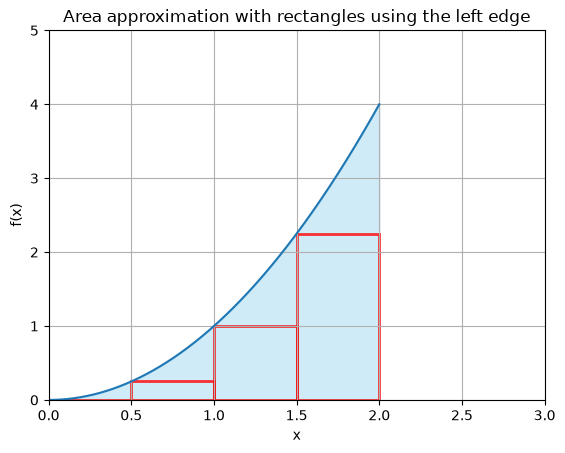

In [4]:
x = np.linspace(0, 2, 1000)
y = x**2

plt.plot(x, y)
plt.fill_between(x, y, color="skyblue", alpha=0.4)

draw_rect(plt.gca(),'r', 0, 0, 0.5, 0)
draw_rect(plt.gca(),'r', 0.5, 0, 0.5, 0.25)
draw_rect(plt.gca(),'r', 1, 0, 0.5, 1)
draw_rect(plt.gca(),'r', 1.5, 0, 0.5, 2.25)

plt.xlim(0, 3)
plt.ylim(0, 5)

plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Area approximation with rectangles using the left edge")
plt.show()


### 2.3 Approximate with the right edge

Let's observe what happens when the approximation is done with the right edge of each interval $x$ values would be $0.5, 1, 1.5, 2$

* First rectangle $f(0.5) = 0.25$, so $A_1 = 0.5 \times 0.25 = 0.125$
* Second rectangle $f(1) = 1$, so $A_2 = 0.5 \times 1 = 0.5$
* Third rectangle $f(1.5) = 2.25$, so $A_3 = 0.5 \times 2.25 = 1.125$
* Fourth rectangle $f(2) = 4$, so $A_4 = 0.5 \times 4 = 2$

Total: $A_R \approx  0.125 + 0.5 + 1.125 + 2 = 3.75$

The left-endpoint approximation underestimates the area, while the right-endpoint approximation overestimates it. 

Therefore, the actual area lies somewhere between these two values $1.75 \lt area \lt 3.75$.


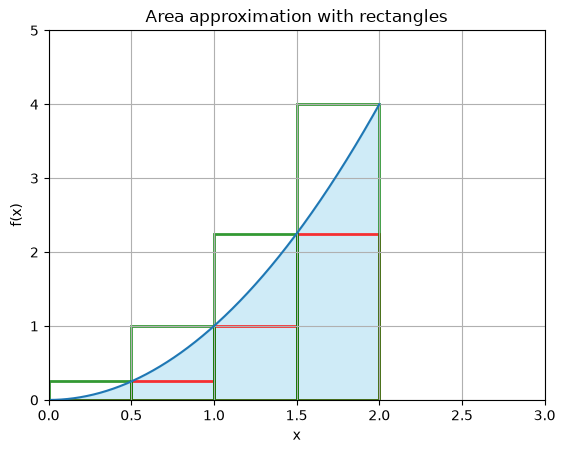

In [5]:
x = np.linspace(0, 2, 1000)
y = x**2

plt.plot(x, y)
plt.fill_between(x, y, color="skyblue", alpha=0.4)

draw_rect(plt.gca(), 'r', 0,   0, 0.5, 0   )
draw_rect(plt.gca(), 'r', 0.5, 0, 0.5, 0.25)
draw_rect(plt.gca(), 'r', 1,   0, 0.5, 1   )
draw_rect(plt.gca(), 'r', 1.5, 0, 0.5, 2.25)

draw_rect(plt.gca(), 'g', 0,   0, 0.5, 0.25)
draw_rect(plt.gca(), 'g', 0.5, 0, 0.5, 1   )
draw_rect(plt.gca(), 'g', 1,   0, 0.5, 2.25)
draw_rect(plt.gca(), 'g', 1.5, 0, 0.5, 4   )

plt.xlim(0, 3)
plt.ylim(0, 5)

plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Area approximation with rectangles")
plt.show()

### 2.4 Riemann Sum

Instead of writing $0.5(0+0.25+1+2.25)$ we can go with:

$$A\approx\sum_{i=1}^{n}f(x_i)\Delta x$$

This type of sum is called a Riemann sum. Where:
* $f(x_i) =$ height of rectangle $i$
* $\Delta x =$ width of the rectangle
* $n =$  number of rectangles

It provides a systematic way of adding the areas of many small rectangles to approximate the area under a curve.


### 2.5 Increasing the Number of Rectangles

Let's observe what happens when we increase the number of rectangles under the curve.

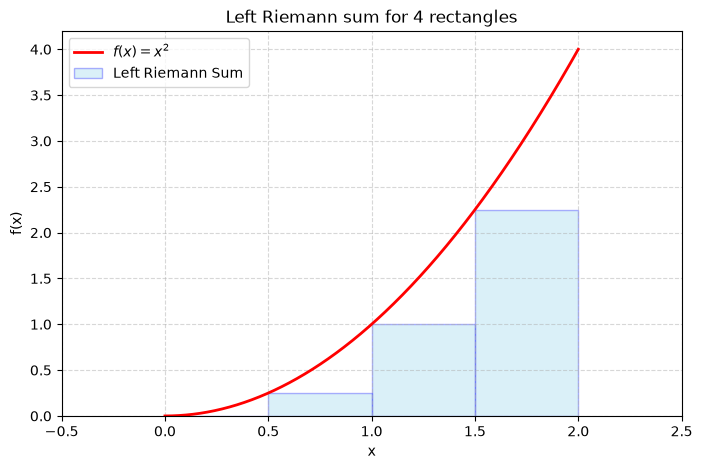

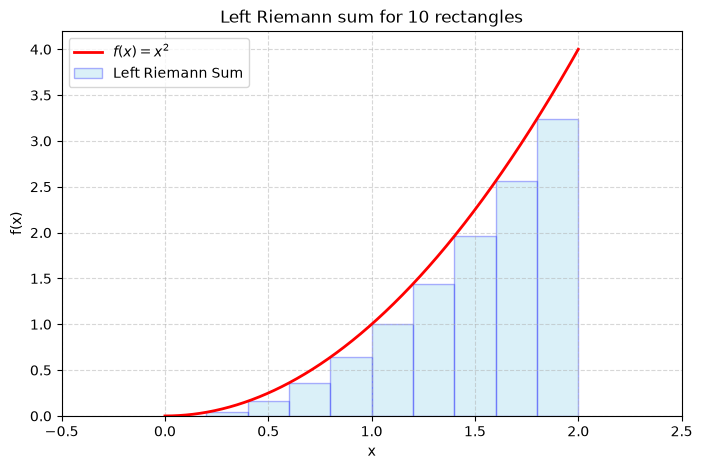

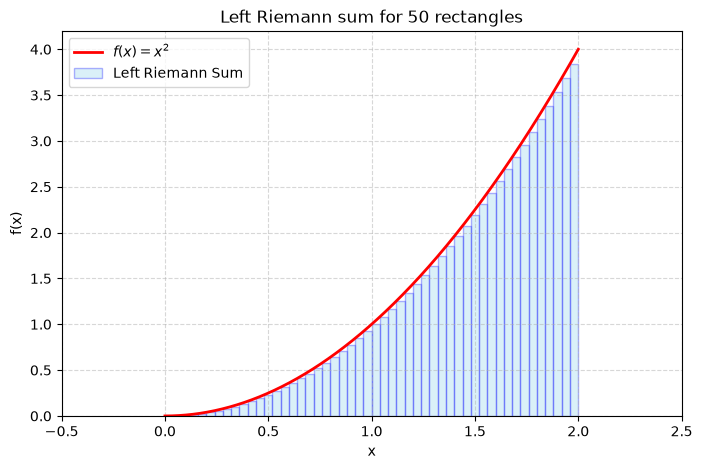

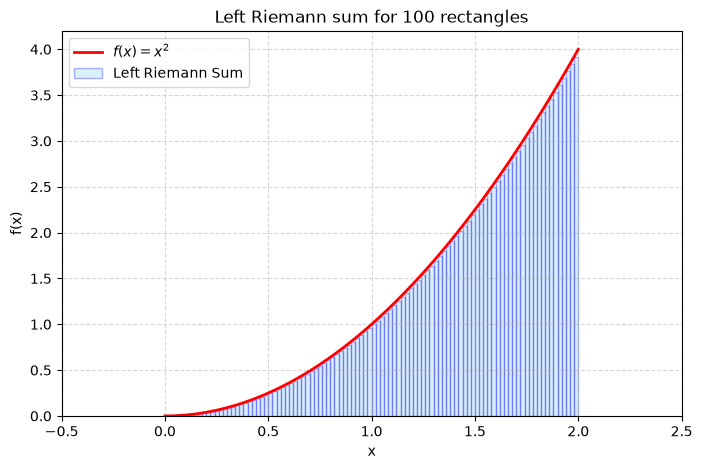

In [6]:
def fx_squared(x):
    return x**2

draw_riemann_rectangles(0, 2, 4, fx_squared)
draw_riemann_rectangles(0, 2, 10, fx_squared)
draw_riemann_rectangles(0, 2, 50, fx_squared)
draw_riemann_rectangles(0, 2, 100, fx_squared)


We can see that as the number of rectangles increases, their width decreases and they follow the curve more closely.

As a result, the approximation becomes more accurate.

### 2.6 Numerical Approximation with Python

We can also calculate the approximations programmatically using Python.

The following results show how the estimated area changes as the number of rectangles increases.

In [7]:
result_n_4 = si.integrate(fx_squared, 0, 2, 4)
result_n_10 = si.integrate(fx_squared, 0, 2, 10)
result_n_100 = si.integrate(fx_squared, 0, 2, 100)
result_n_1000 = si.integrate(fx_squared, 0, 2, 1000)
result_n_10000 = si.integrate(fx_squared, 0, 2, 10000)

data = {
    "Number of rectangles (n)": [4, 10, 100, 1000, 10000],
    "Calculated area": [result_n_4, result_n_10, result_n_100, result_n_1000, result_n_10000]
}
df = pd.DataFrame(data)

df.index = df.index + 1

df.style.format({"Calculated area": "{:.4f}"})

,Number of rectangles (n),Calculated area
1,4,1.7500
2,10,2.2800
3,100,2.6268
4,1000,2.6627
5,10000,2.6663


## 3. From Approximation to the Definite Integral

### 3.1 From Rectangle Approximation to a Limit

In the previous chapter, we approximated the area under $f(x) = x^2$ using rectangles.

Each rectangle has a width $\Delta x$ and a height determined by the function. 

The total area is obtained by adding the areas of all rectangles.

$$A \approx \sum_{i=1}^{n} f(x_i)\Delta x$$

The formula can be interpreted as follows:

* $n$ - the number of rectangles
* $\Delta x$ - width of each rectangle
* $f(x_i)$ - height of a rectangle
* $f(x_i)\Delta x$ - area of one rectangle
* $\sum$ - the sum of all rectangle areas

See a visualisation for 100 rectangles [here](#26-numerical-approximation-with-python)

What would happen if we continued increasing the number of rectangles? 

Let's consider what happens as $n \rightarrow \infty$. As $n$ increases $\Delta x \rightarrow 0$. 

The rectangles become narower, and the approximation gets closer to the actual area.

| Rectangles | Approximation | 
| :--- | :---: | 
| 4 rectangles                      | Rough | 
| 10 rectangles                     | Better | 
| 100 rectangles                    | Very close | 
| 1000 rectangles                   | Extremely close | 
| $n \rightarrow \infty$ rectangles | Exact value |

We are not actually calculating the area of an infinite number of rectangles.

We are interested in the value that the approximation approaches as the number of rectangles becomes arbitrarily large.

### 3.2 From the Limit to the Definite Integral


The idea of using increasingly many, increasingly smaller rectangles can be expressed as:

$$A=\lim_{n\rightarrow\infty}\sum_{i=1}^{n}f(x_i)\Delta x$$

This can also be expressed using integral notation:

$$A=\int_a^b f(x)\,dx$$

The formula can be interpreted as follows:
* $\int$ - represents integration
* $a$ - lower bound of the interval
* $b$ - upper bound of the interval
* $f(x)$ - function being integrated
* $dx$ - small change in $x$

For our example: $$A=\int_0^2x^2\,dx$$

The definite integral represents the exact accumulated area under $f(x)=x^2$ between $x=0$ and $x=2$.

### 3.3 Calculating the Integral Analytically

#### The Power Rule
To calculate an integral, we can use specific integration rules. One of the most fundamental is the Power Rule of Integration, which reverses the Power Rule of Differentiation:

* Add $1$ to the exponent ($n+1$)
* Divide by the new exponent
* Add $+C$, the constant of integration 
    * We add $+C because the derivative of any constant is zero. When reversing the differentiation process, we therefore cannot determine whether a constant was present originally.

$$ \int x^n dx = \frac{x^{n+1}}{n+1} + C \, (n \neq -1)$$

For our function:
$$\int x^2dx=\frac{x^3}{3}+C$$
$$\int_0^2x^2dx=\left[\frac{x^3}{3}\right]_0^2$$
$$A =\frac{2^3}{3}-\frac{0^3}{3} =\frac83$$
$$\boxed{A=\frac83\approx2.6667}$$

### 3.4 Numerical vs. Analytical Results

In [8]:
exact = 8 / 3
approximation = result_n_10000

error = abs(exact - approximation)

print(f"Our analytical solution gives: {exact:.4f}")
print(f"Using the rectangle approximation in Python, we obtain: {approximation:.4f}")
print(f"The difference between the exact value and the numerical approximation can be expressed as the Error = |{error:.4f}|")

Our analytical solution gives: 2.6667
Using the rectangle approximation in Python, we obtain: 2.6663
The difference between the exact value and the numerical approximation can be expressed as the Error = |0.0004|


The numerical method does not give the exact value because it uses a finite number of rectangles. 

However, increasing the number of rectangles makes the approximation increasingly close to the analytical result.

### 3.5 Visualizing the Convergence


We can also visualize how the numerical approximation approaches the exact value as the number of rectangles increases.

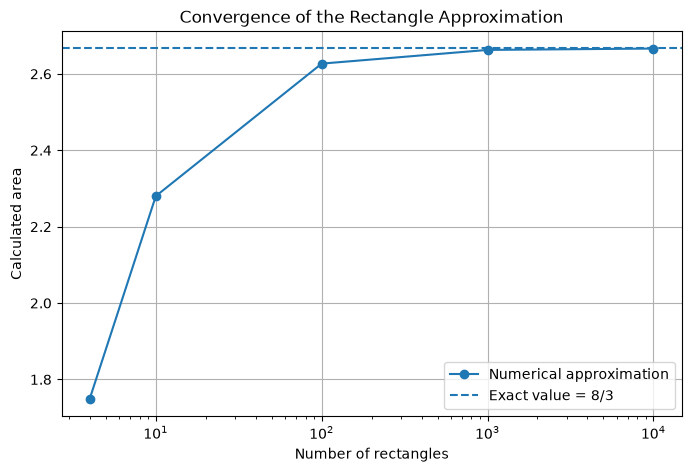

In [9]:
x_values = [4, 10, 100, 1000, 10000] # number of rectangles
y_values = [
    result_n_4,
    result_n_10,
    result_n_100,
    result_n_1000,
    result_n_10000
] # calculated approximations

plt.figure(figsize=(8, 5))

plt.plot(x_values, y_values, marker="o", label="Numerical approximation")

plt.axhline(
    8/3,
    linestyle="--",
    label="Exact value = 8/3"
)

plt.xscale("log")

plt.xlabel("Number of rectangles")
plt.ylabel("Calculated area")
plt.title("Convergence of the Rectangle Approximation")

plt.grid(True)
plt.legend()
plt.show()


The graph shows that the calculated area approaches the exact value of $\frac83$ as the number of rectangles increases.

### 3.6 Chapter Summary

In this chapter, we saw how the rectangle approximation leads to the definite integral. 

As the number of rectangles increases, the approximation approaches an exact value.

For the function $f(x)=x^2$ on the interval $[0,2]$, the exact area is:
$$\int_0^2x^2\,dx=\frac83\approx2.6667$$

The numerical approximation using rectangles approaches this value as the number of rectangles increases.

This example demonstrates how integration can be used to calculate area.

However, integrals can also be used to calculate many quantities that are not directly related to geometric area. 

The next chapter explores one such application: calculating distance from velocity.

## 4. Application 1: From Velocity to Distance

### 4.1 A Changing Velocity

Let's consider an object whose velocity changes linearly over time. 

$$ v(t)=2t,\qquad 0\leq t\leq5$$

The formula can be interpreted as follows:
* $t$ is time in seconds
* $v(t)$ is velocity in metres per second

We can calculate some values based on the formula above.

| Time $t$ | Velocity $v(t) = 2t$ | 
| :--- | :---: | 
| 0 s  | 0 m/s| 
| 1 s  | 2 m/s| 
| 2 s  | 4 m/s| 
| 3 s  | 6 m/s| 
| 4 s  | 8 m/s| 
| 5 s  | 10 m/s| 

From this, we can see that the velocity changes continuously over time. This creates the following problem:

How far did the object travel during these 5 seconds?

If we have a constant velocty , we can easily calculate the distance using: $$ d = v \cdot t$$ 

For example, if a car travels at a constant speed of $10m/s$ for $5$ seconds: $$ d = 10 \cdot 5 = 50m$$

In our example, the velocity starts at $0\,m/s$ and ends at $10\,m/s$. So what value of $v$ should we use in $d=v\cdot t$?

There isn not a single velocity that describes the entire 5-second interval.

### 4.2 Distance as the Area Under a Velocity-Time Curve


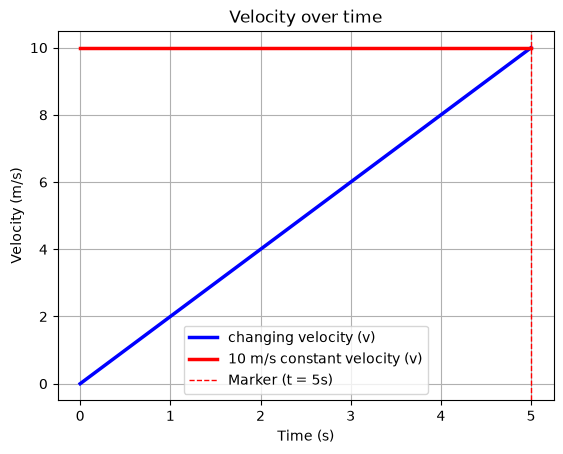

In [10]:
t = np.linspace(0, 5, 100)
v = 2*t
v_constant = np.full_like(t, 10)

plt.plot(t, v, color='blue', linewidth=2.5, label='changing velocity (v)')
plt.plot(t, v_constant, color='red', linewidth=2.5, label='10 m/s constant velocity (v)')
plt.axvline(x=5, color='red', linestyle='--', linewidth=1, label='Marker (t = 5s)')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity over time")
plt.grid(True)
plt.legend()
plt.show()

For constant velocity, the area under the velocity-time graph is: $$A = v \cdot t$$

Since velocity is measured in $m/s$ and time in seconds: $$ \frac{m}{s} \cdot s = m$$ 

Therefore, the area under a velocity-time graph represents a distance.

#### What happens with changing velocity?

Our graph is: $$v(t)=2t $$

The area under it is now a triangle rather than a rectangle.
You could actually calculate it using the triangle formula: $$A=\frac12bh$$
$$b=5\,s,\qquad h=10\,m/s$$
$$A=\frac{1}{2}(5)(10)=25\,m$$


This gives us:$$\boxed{d=25\,m}$$

In this particular example, the area under the curve forms a simple triangle, so we can calculate it using a geometric formula.

However, velocity-time graphs do not generally form simple geometric shapes. In such cases, geometric formulas are not sufficient, and we need a more general method.

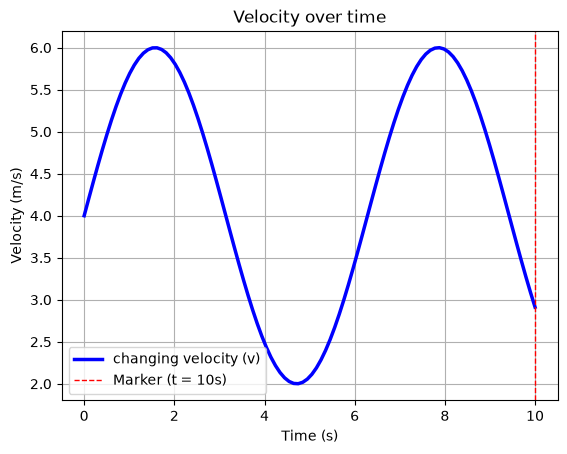

In [11]:
t = np.linspace(0, 10, 100)
v = 4 + 2*np.sin(t)

plt.plot(t, v, color='blue', linewidth=2.5, label='changing velocity (v)')
plt.axvline(x=10, color='red', linestyle='--', linewidth=1, label='Marker (t = 10s)')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity over time")
plt.grid(True)
plt.legend()
plt.show()

### 4.3 Approximating the Distance with Rectangles

Instead of relying on the geometric shape of this particular graph, we can use the rectangle approximation method introduced earlier.

Divide: $$0\leq t\leq5$$ into 5 intervals.

Therefore: $$\Delta t=\frac{5-0}{5}=1$$

#### Left approximation
Using left endpoints, the velocities are: $v(0)=0$, $v(1)=2$, $v(2)=4$, $v(3)=6$, $v(4)=8$

So the approximate distance is: $$d\approx0(1)+2(1)+4(1)+6(1)+8(1)$$ $$d\approx20\,m$$

We see that: $$20\,m < 25\,m$$ 

That's because we are using left endpoints. Since the velocity is increasing, every rectangle lies below the velocity curve.

#### Right approximation
Using the right endpoints  $v(1)$, $v(2)$, $v(3)$, $v(4)$, $v(5)$ we get:
$$ d\approx2+4+6+8+10$$
$$d\approx30\,m$$

Then: $$20<25<30$$

Therefore the actual distance is bounded by the left- and right-endpoint approximations.


### 4.4 Calculating the Exact Distance with an Integral


We know: $$ d=\int_{t_0}^{t_1}v(t)\,dt $$
For our example: $$d=\int_0^5 2t\,dt$$
Using the Power Rule of Integration: $$\int2t\,dt=t^2$$
Therefore:$$d=\left[t^2\right]_0^5$$
$$d=5^2-0^2$$
$$d=25\,m$$

And now the three approaches agree:

| Method | Distance |
| :--- | :--- |
| **Left rectangles** | 20 m |
| **Right rectangles** | 30 m |
| **Exact integral** | 25 m |

### 4.5 Visualizing the Distance as Area

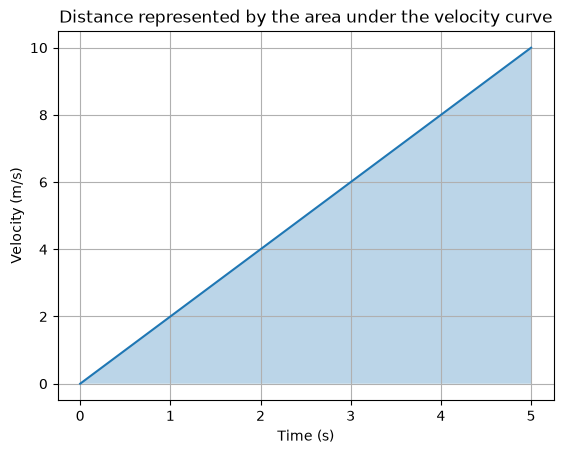

In [12]:
t = np.linspace(0, 5, 100)
v = 2 * t

plt.plot(t, v)
plt.fill_between(t, v, alpha=0.3)

plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Distance represented by the area under the velocity curve")
plt.grid(True)
plt.show()

The shaded area represents the distance travelled during the 5-second interval. $$\boxed{\text{Distance}=25\,m}$$

### 4.6 Numerical vs. Analytical Distance

We can calculate the approximations programmatically using Python.

The following results show how the estimated distance changes as the number of rectangles increases.

In [13]:
def velocity(t):
    return t * 2

distance_n_5 = si.integrate(velocity, 0, 5, 5)
distance_n_10 = si.integrate(velocity, 0, 5, 10)
distance_n_50 = si.integrate(velocity, 0, 5, 50)
distance_n_100 = si.integrate(velocity, 0, 5, 100)
distance_n_1000 = si.integrate(velocity, 0, 5, 1000)

data = {
    "Number of rectangles (n)": [5, 10, 50, 100, 1000],
    "Calculated area": [distance_n_5, distance_n_10, distance_n_50, distance_n_100, distance_n_1000]
}
df = pd.DataFrame(data)

df.index = df.index + 1

df.style.format({"Calculated area": "{:.4f}"})

,Number of rectangles (n),Calculated area
1,5,20.0000
2,10,22.5000
3,50,24.5000
4,100,24.7500
5,1000,24.9750


As the number of rectangles increases, the numerical approximation approaches the exact distance of $25 m$.



### 4.7 What We Learned

In this example, integration allowed us to calculate the total distance travelled by an object with changing velocity.

The distance travelled can be represented by the area under a velocity-time curve: $$ d=\int_{t_0}^{t_1}v(t)\,dt $$

Unlike the simple formula $d=v\cdot t$, integration can be used when velocity changes continuously over time.

This demonstrates one of the most important ideas behind integration: it can be used to calculate a total quantity from a changing rate.

## 5. Application 2: Variable Force and Work

### 5.1 What Is Work?

Mechanical work describes the energy transferred when a force moves an object over a distance. The relationship is directly proportional.

* More Force = More Work, for example if you push a cart with twice the force over the exact same distance, you transfer twice the energy (doubling the work)
* More Distance = More Work, if you maintain the same force but push the cart for 10 meters instead of 1 meter, you perform 10 times the work.

Under a constant force, every single meter of movement requires the exact same amount of energy, thus we can easily calculate the work using: $$ W = F \cdot d$$ 

where:
* $W$ = work, measured in joules(J)
* $F$ = force, measured in newtons (N)
* $d$ = distance, measured in metres (m)

Note: $W=F\cdot d$ assumes the force is constant and acts in the direction of movement.

### 5.2 What If the Force Changes?

As with velocity in Chapter 4, the force applied to an object can change over time or displacement.

We will use a simplified quadratic force model $$F(x) = kx^2$$

Here, $x$ represents the displacement from the starting position, and $k$ is a constant. The quadratic model means that the force increases proportionally to the square of the displacement.

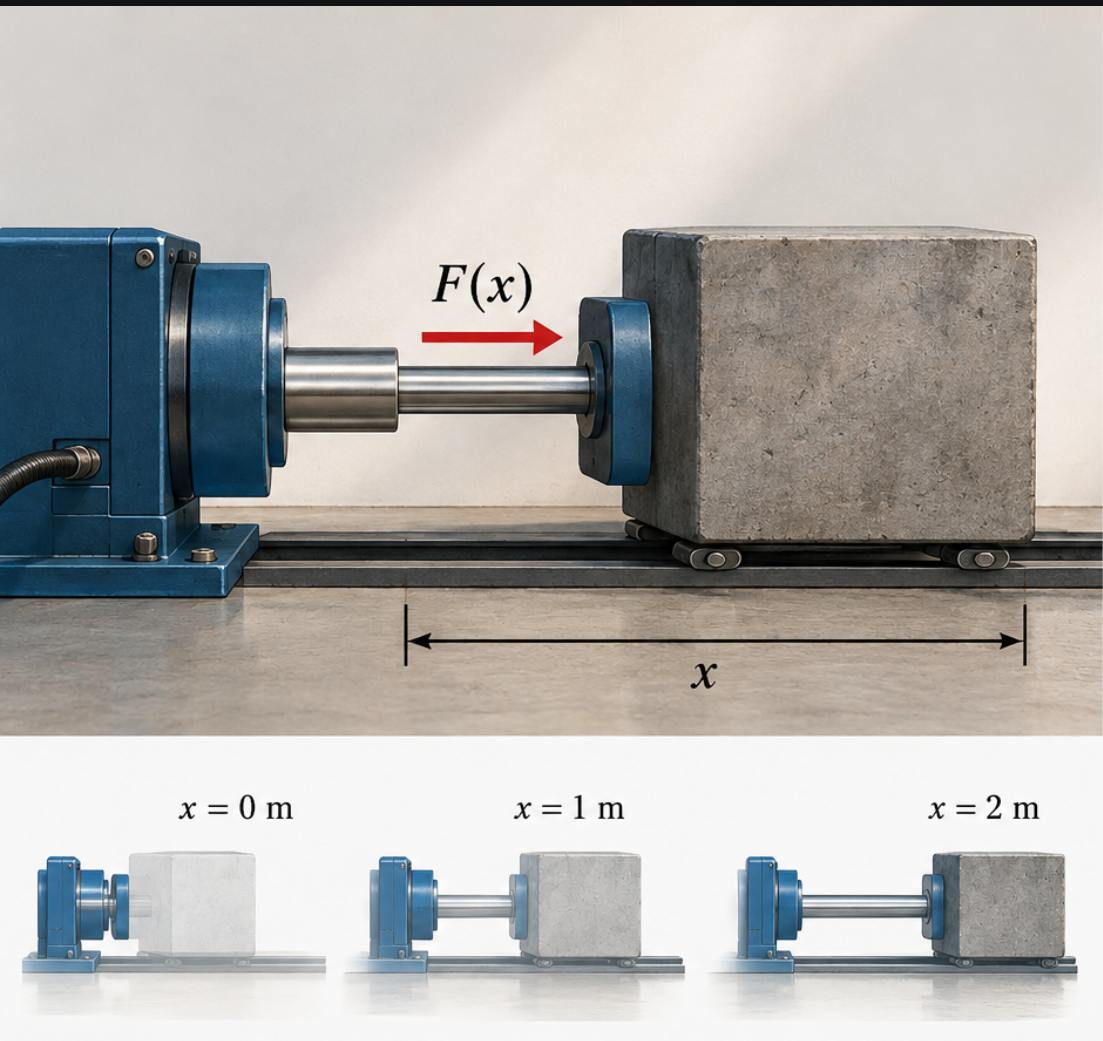

For easier calculations we will set: $$k=20\ \text{N/m}^2,\qquad 0\leq x\leq2\ \text{m}$$

The force therefore increases from $0N$ to $80N$ as object is moved by $2 m$.

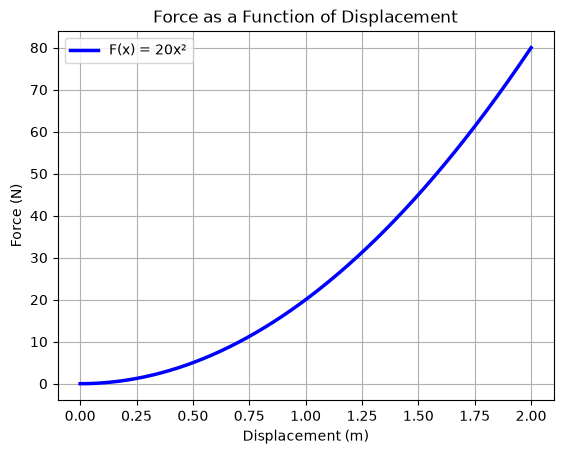

In [28]:
x = np.linspace(0, 2, 1000)
F = 20* x**2

plt.plot(x, F, color='blue', linewidth=2.5, label="F(x) = 20x²")
plt.xlabel("Displacement (m)")
plt.ylabel("Force (N)")
plt.title("Force as a Function of Displacement")
plt.grid(True)
plt.legend()
plt.show()

### 5.3 Approximating Work with Rectangles

Let's compare the left- and right-endpoint approximations for $F(x) = 20x^2$ over the interval $0\leq x\leq2$, divided into four equal sections.

Therefore: $$\Delta x=\frac{2-0}{4}=0.5$$

For $f(0) = 20\times0^2$ we have $0$, following the same logic we calculate:

| Rectangle | Left force (N) | Right force (N)|
| :---      | :---:          | :---: | 
|1          | $F(0)=0$       | $F(0.5)=5$| 
|2          | $F(0.5)=5$     | $F(1)=20$| 
|3          | $F(1)=20$      | $F(1.5)=45$| 
|4          | $F(1.5)=45$    | $F(2)=80$| 

$f(x) \times \Delta x$ gives us:

* Left approximation: $W_L=0.5(0+5+20+45)=35\text{ J}$
* Right approximation: $ W_R=0.5(5+20+45+80)=75\text{ J}$

Because the force increases over the interval, the left-endpoint rectangles underestimate the work, while the right-endpoint rectangles overestimate it. As we increase the number of rectangles, both approximations get closer to the exact value.


### 5.4 Calculating Work with an Integral

We know: $$ W=\int_{a}^{b}F(x)\,dx $$
For our example: $$ W=\int_{0}^{2}20x^2\,dx $$
Using the Power Rule of Integration: $$\int20x^2\, dx=\frac{20x^3}{3}$$
$$\begin{aligned}W&=\left[\frac{20x^3}{3}\right]_0^2\\&=\frac{20(2^3)}{3}-\frac{20(0^3)}{3}\\&=\frac{160}{3}\\&\approx53.33\text{ J}\end{aligned}$$

And now the three approaches agree:

| Method | Work |
| :--- | :--- |
| **Left rectangles** | $35 \text{ J}$ |
| **Right rectangles** | $75 \text{ J}$ |
| **Exact integral** | $53.33 \text{ J}$ |



### 5.5 Visualizing the Force as Area

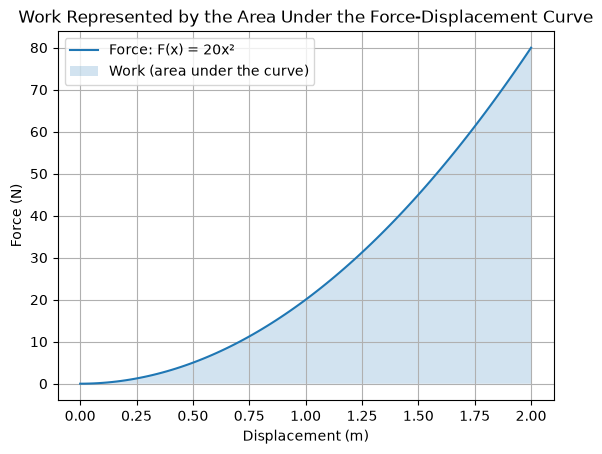

In [35]:
x = np.linspace(0, 2, 100)
F = 20 * x ** 2

plt.plot(x, F, label="Force: F(x) = 20x²")
plt.fill_between(x, F, alpha=0.2, label="Work (area under the curve)")

plt.xlabel("Displacement (m)")
plt.ylabel("Force (N)")
plt.title("Work Represented by the Area Under the Force-Displacement Curve")
plt.legend()
plt.grid(True)
plt.show()

### 5.6 Numerical vs. Analytical Results

We can again calculate the approximations programmatically using Python.

The following results show how the estimated work changes as the number of rectangles increases.

In [30]:
def force(x):
    return 20 * x ** 2

work_n_4 = si.integrate(force, 0, 2, 4)
work_n_10 = si.integrate(force, 0, 2, 10)
work_n_50 = si.integrate(force, 0, 2, 50)
work_n_100 = si.integrate(force, 0, 2, 100)
work_n_1000 = si.integrate(force, 0, 2, 1000)

data = {
    "Number of rectangles (n)": [4, 10, 50, 100, 1000],
    "Calculated work": [work_n_4, work_n_10, work_n_50, work_n_100, work_n_1000]
}
df = pd.DataFrame(data)

df.index = df.index + 1

df.style.format({"Calculated work": "{:.4f}"})

,Number of rectangles (n),Calculated work
1,4,35.0000
2,10,45.6000
3,50,51.7440
4,100,52.5360
5,1000,53.2534


As the number of rectangles increases, the numerical approximation approaches the exact work of $53.33 \text{ J}$.



## 6. Application 3: Probability

## 7. Going Beyond One Dimension: Multiple Integrals

## 8. A Real-World Multiple-Integral Application
### Volume of a surface 
$$f(x,y)=4-x^2-y^2$$
over a simple square region, for example:
$$0\leq x\leq2,\qquad 0\leq y\leq2$$
$$V\approx\sum f(x_i,y_j)\Delta x\Delta y$$

## 9. Conclusions
### 9.1 What We Learned
### 9.2 Why Integrals Are Useful
### 9.3 Extensions
* Triple integrals
* Physics
* Engineering
* Statistics
* Economics
* Machine learning / data science


$$ \int_a^b f(x)dx = \lim\limits_{n\rightarrow\infty} \sum\limits_{i=1}^{n} f(x_i)\Delta x $$